# Proper Scoring Rules for Survival Analysis - Reproduction

**Student:** Saba Naji  
**Course:** Advanced Statistical Machine Learning (MSc) - Spring 2026  
**Selected paper:** Hiroki Yanagisawa, *Proper Scoring Rules for Survival Analysis*, ICML 2023

## Goal

This notebook reproduces the main idea of the selected paper with the three original public datasets:

- `flchain`
- `prostateSurvival`
- `support`

I implement the four scoring-rule methods studied in the paper:

1. **Portnoy** - censored pinball loss / quantile regression
2. **Cen-log** - censored logarithmic score
3. **Cen-Brier** - censored Brier score
4. **Cen-RPS** - censored ranked probability score

I also reproduce two smaller studies from the paper: the effect of the number of time bins `B` and the effect of the DeepHit ranking parameter `alpha` (Table 1). DeepHit is the
loss in this notebook that is not proved to be proper, so it plays the role of the improper
baselines of Figure 4.

Finally I test a small extension called **Hybrid**, which uses 50% Cen-log and 50% Cen-Brier.


## 1. Software environment and settings

I ran this notebook on my own laptop with the CPU only. I used Python 3.14 and PyTorch 2.12.1, together with NumPy, pandas, scikit-learn and matplotlib. The paper used Python 3.7.4 and PyTorch 1.7.1 on a CPU machine, so the tools are newer here but the setup is the same kind.

The three CSV files are exports of the R datasets used in the paper: `flchain` from the `survival` package, `prostateSurvival` from the `asaur` package, and `support` from the `casebase` package. I saved each of them as a CSV file in the `data/` folder of this repository.

I keep the main model settings of the paper: 32 time bins, three hidden layers with 128 neurons, ReLU after each hidden layer, softmax at the output, the Adam optimizer with learning rate 0.001, and five random 60/20/20 splits. I use 75 epochs instead of 300 so that the notebook finishes in a reasonable time on a CPU, and I set the seed to 42 so the results can be repeated. In the two smaller studies of Sections 17 and 18 I use three runs instead of five for the same reason.

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)
B=32
runs=5
small_runs=3
epochs=75
check=25
lr=.001
eps=1e-7

print(torch.__version__)

2.12.1+cpu


## 2. Load the original datasets

The CSV files below are exports of the same R datasets named in the paper.

In [2]:
flchain = pd.read_csv("../data/flchain.csv")
prostate = pd.read_csv("../data/prostateSurvival.csv")
support = pd.read_csv("../data/support.csv")

print(flchain.shape)
print(prostate.shape)
print(support.shape)

(7874, 11)
(14294, 5)
(9104, 34)


## 3. Preprocessing

For each dataset, I used `X` as the input features, `time` as the observed time, and `event` to show if the event happened.

For `flchain`, I removed missing `creatinine` values and the `chapter` column. For `prostateSurvival`, I used `status > 0` as an observed death. For `support`, I removed `slos`.

Categorical variables were changed to dummy variables, and missing numeric values were filled with the median. Zero survival times were changed to `0.001`.

Some preprocessing details are not fully explained in the paper, so my results may be a little different.

In [3]:
def prep(name):
    if name == "flchain":
        df=flchain.dropna(subset=["creatinine"]).copy()
        time=df["futime"].values.astype(float)
        event=df["death"].values.astype(float)
        X=df.drop(columns=["futime","death","chapter"])
    elif name == "prostateSurvival":
        df=prostate.copy()
        time=df["survTime"].values.astype(float)
        event=(df["status"].values>0).astype(float)
        X=df.drop(columns=["survTime","status"])
    else:
        df=support.copy()
        time=df["d.time"].values.astype(float)
        event=df["death"].values.astype(float)
        X=df.drop(columns=["d.time","death","slos"])
        
    # time must be positive, so zero times become a very small value
    time[time<=0]=.001

    for c in X.columns:
        if pd.api.types.is_numeric_dtype(X[c]):
            X[c]=X[c].fillna(X[c].median())
        else:
            X[c]=X[c].fillna("Missing")
    # turn the text columns into 0/1 columns so the network can use them
    X=pd.get_dummies(X,drop_first=True).astype(float)
    return X,time,event,[name,len(X),X.shape[1],1-event.mean(),time.max()]

prepared={}
rows=[]
for name in ["flchain","prostateSurvival","support"]:
    X,time,event,info=prep(name)
    prepared[name]=(X,time,event)
    rows.append(info)

info_table=pd.DataFrame(rows,columns=["Dataset","Rows","Features","Censoring","Max time"])
info_table.round(4)

,Dataset,Rows,Features,Censoring,Max time
0,flchain,6524,8,0.6993,5166.0
1,prostateSurvival,14294,6,0.7174,119.0
2,support,9104,44,0.3190,2029.0


## 4. Time grid and neural networks

I divided the time range into 32 intervals. The distribution model gives 32 probabilities using softmax.

For Portnoy, the model gives 31 increasing quantiles. I used cumulative positive values so the quantiles always stay in the correct order.

In [4]:
def make_edges(time):
    return np.linspace(0,time.max()+.001,B+1).astype("float32")

def time_bin_torch(time,edges):
    return torch.bucketize(time,edges[1:-1])

class DistributionNet(nn.Module):
    def __init__(self,p):
        super().__init__()
        self.l1=nn.Linear(p,128)
        self.l2=nn.Linear(128,128)
        self.l3=nn.Linear(128,128)
        self.out=nn.Linear(128,B)

    def forward(self,x):
        x=torch.relu(self.l1(x))
        x=torch.relu(self.l2(x))
        x=torch.relu(self.l3(x))
        x=self.out(x)
        # softmax gives the B bin probabilities, and they always sum to one
        return torch.softmax(x,dim=1)

class QuantileNet(nn.Module):
    def __init__(self,p,zmax):
        super().__init__()
        self.zmax=zmax
        self.l1=nn.Linear(p,128)
        self.l2=nn.Linear(128,128)
        self.l3=nn.Linear(128,128)
        self.out=nn.Linear(128,B)

    def forward(self,x):
        x=torch.relu(self.l1(x))
        x=torch.relu(self.l2(x))
        x=torch.relu(self.l3(x))
        x=torch.softmax(self.out(x),dim=1)
        x=x*self.zmax
        # the cumulative sum keeps the quantiles in increasing order
        x=torch.cumsum(x,dim=1)
        return x[:,:-1]

## 5. CDF helper

For censored data, I estimate the CDF at the censoring time using linear interpolation. These values are used as weights during training.

In [5]:
def cdf_at_time(time,edges,F):
    j=time_bin_torch(time,edges)
    r=torch.arange(len(time))
    a=edges[j]
    b=edges[j+1]
    f1=F[r,j]
    f2=F[r,j+1]
    # linear interpolation inside the bin, because the time is not exactly on an edge
    x=((time-a)/(b-a+eps)).clamp(0,1)

    return f1+x*(f2-f1)

## 6. Loss functions

I implemented the four loss functions from the paper: Cen-log, Cen-Brier, Cen-RPS, and Portnoy.

In [6]:
def cen_log_loss(f,time,event,edges):
    n=len(time)
    F=torch.zeros((n,B+1))
    F[:,1:]=torch.cumsum(f,dim=1)
    j=time_bin_torch(time,edges)
    r=torch.arange(n)

    p=f[r,j].clamp_min(eps)
    Fn=F[r,j+1]
    # F(c) at the censoring time; detach because the IR algorithm treats the weight as fixed
    Fc=cdf_at_time(time,edges,F).detach()
    Fc=Fc.clamp(max=1-eps)
    # this is the weight w_i of Equation 4
    w=(Fn.detach()-Fc)/(1-Fc+eps)
    w=w.clamp(0,1)
    loss1=-torch.log(p)
    loss2=-(w*torch.log(p)+(1-w)*torch.log((1-Fn).clamp_min(eps)))
    # uncensored rows use the first term, censored rows use the weighted one
    loss=event*loss1+(1-event)*loss2
    return loss.mean()

In [7]:
def cen_brier_loss(f,time,event,edges):
    n=len(time)
    F=torch.zeros((n,B+1))
    F[:,1:]=torch.cumsum(f,dim=1)

    j=time_bin_torch(time,edges)
    Fc=cdf_at_time(time,edges,F).detach()
    Fc=Fc.clamp(max=1-eps)
    target=torch.zeros((n,B))
    # build the target vector w_i of Equation 8, one bin at a time
    for k in range(B):
        t1=(j==k).float()
        t2=torch.zeros(n)
        after=j<k
        # for a censored row the remaining mass is spread over the later bins
        t2[after]=f.detach()[after,k]/(1-Fc[after]+eps)
        same=j==k
        w=(F.detach()[same,k+1]-Fc[same])/(1-Fc[same]+eps)
        t2[same]=w.clamp(0,1)
        target[:,k]=event*t1+(1-event)*t2

    target=target/target.sum(dim=1,keepdim=True).clamp_min(eps)
    loss=(target*(1-f)**2+(1-target)*f**2).sum(dim=1)

    return loss.mean()

In [8]:
def cen_rps_loss(f,time,event,edges):
    n=len(time)
    F=torch.zeros((n,B+1))
    F[:,1:]=torch.cumsum(f,dim=1)
    Fc=cdf_at_time(time,edges,F).detach()
    Fc=Fc.clamp(max=1-eps)
    loss=torch.zeros(n)
    # Equation 9 is a sum of binary Brier scores over all thresholds
    for k in range(1,B):
        pred=F[:,k]
        z=edges[k]
        t1=(time<=z).float()
        t2=torch.zeros(n)
        w=(pred.detach()-Fc)/(1-Fc+eps)
        w=w.clamp(0,1)
        after=time<z
        t2[after]=w[after]
        target=event*t1+(1-event)*t2
        loss=loss+(target-pred)**2

    return loss.mean()

In [9]:
def pinball(q,y,tau):
    a=tau*(y-q)
    b=(1-tau)*(q-y)
    return torch.maximum(a,b)

def portnoy_loss(q,time,event,zmax):
    # rough estimate of tau_c = F(c) from the current quantiles
    tc=(q.detach()<=time[:,None]).sum(dim=1).float()/B
    # z_infinity: a constant larger than the largest possible time
    z=time*0+zmax*1.1+.001
    loss=0
    for k in range(1,B):
        tau=k/B
        qk=q[:,k-1]
        w=(tau-tc)/(1-tc+eps)
        w=w.clamp(0,1)
        # the case tau_c > tau in the paper, where the second term is not needed
        w[tc>tau]=1
        loss1=pinball(qk,time,tau)
        loss2=w*loss1+(1-w)*pinball(qk,z,tau)
        loss=loss+(event*loss1+(1-event)*loss2)

    return loss.mean()/(B-1)

### 6.1 Two extra losses

For Section 17 I also need the simplified logarithmic score of Equation 5. It is the same as
Cen-log but with the weight fixed to zero, so a censored point only gets the survival term.

For Section 18 I need DeepHit. Its loss is the simplified logarithmic score plus a ranking term
controlled by `alpha`. The ranking term compares pairs of patients, so I compute it on a random
subset of the training rows to keep it fast.

In [10]:
# Equation 5: the simple version of Cen-log, it assumes the weight is zero
def cen_log_simple_loss(f,time,event,edges):
    n=len(time)
    F=torch.zeros((n,B+1))
    F[:,1:]=torch.cumsum(f,dim=1)
    j=time_bin_torch(time,edges)
    r=torch.arange(n)
    p=f[r,j].clamp_min(eps)
    S=(1-F[r,j+1]).clamp_min(eps)
    loss=-event*torch.log(p)-(1-event)*torch.log(S)
    return loss.mean()

# the second term of DeepHit, it rewards a correct ranking between two patients
def ranking_term(f,time,event,edges,size=400,sigma=.1):
    n=len(time)
    # only a random subset of rows, because all pairs would be too slow on CPU
    pick=torch.randperm(n)[:min(size,n)]
    g=f[pick]
    m=len(pick)
    F=torch.zeros((m,B+1))
    F[:,1:]=torch.cumsum(g,dim=1)
    j=time_bin_torch(time[pick],edges)
    Fk=F[:,j+1]
    own=torch.diagonal(Fk)
    ok=(event[pick][:,None]>.5)&(time[pick][:,None]<time[pick][None,:])
    pen=torch.exp(-(own[:,None]-Fk.t())/sigma)
    return (ok.float()*pen).sum()/m

def deephit_loss(f,time,event,edges,alpha):
    loss=cen_log_simple_loss(f,time,event,edges)
    if alpha>0:
        loss=loss+alpha*ranking_term(f,time,event,edges)
    return loss

## 7. Training

I trained the models with Adam using the full training set in each epoch. I used a 60/20/20 split
for training, validation, and testing.

The paper does not say how it uses the validation split. I use it in the usual way: every 25
epochs I measure Cen-log-simple on the validation set and at the end I keep the weights of the
best checkpoint. This is what stops the model from overfitting after a certain point.

In [11]:
def predict_bins(model,x,edges,method):
    with torch.no_grad():
        out=model(torch.tensor(x,dtype=torch.float32))
    if method=="Portnoy":
        return quantiles_to_bins(out.numpy(),edges)
    return out.numpy()

def train_model(x,time,event,edges,method,seed,val=None,alpha=1.):
    torch.manual_seed(seed)
    x_np=x
    edges_np=edges
    x=torch.tensor(x,dtype=torch.float32)
    time=torch.tensor(time,dtype=torch.float32)
    event=torch.tensor(event,dtype=torch.float32)
    edges=torch.tensor(edges,dtype=torch.float32)

    if method=="Portnoy":
        model=QuantileNet(x.shape[1],float(edges[-1]))
    else:
        model=DistributionNet(x.shape[1])
    opt=torch.optim.Adam(model.parameters(),lr=lr)
    best_score=1e10
    best_weights=None
    # full-batch training, one update per epoch
    for i in range(epochs):
        opt.zero_grad()
        if method=="Portnoy":
            q=model(x)
            loss=portnoy_loss(q,time,event,float(edges[-1]))
        else:
            f=model(x)
            if method=="Cen-log":
                loss=cen_log_loss(f,time,event,edges)
            elif method=="Cen-Brier":
                loss=cen_brier_loss(f,time,event,edges)
            elif method=="Cen-RPS":
                loss=cen_rps_loss(f,time,event,edges)
            elif method=="Cen-log-simple":
                loss=cen_log_simple_loss(f,time,event,edges)
            elif method=="DeepHit":
                loss=deephit_loss(f,time,event,edges,alpha)
            else:
                loss=.5*cen_log_loss(f,time,event,edges)+.5*cen_brier_loss(f,time,event,edges)

        loss.backward()
        opt.step()
        # check the validation score every 25 epochs and keep the best weights
        if val is not None and (i+1)%check==0:
            fv=predict_bins(model,val[0],edges_np,method)
            score=cen_log_simple_metric(fv,val[1],val[2],edges_np)
            if score<best_score:
                best_score=score
                best_weights=copy.deepcopy(model.state_dict())
    # go back to the best checkpoint instead of the last epoch
    if best_weights is not None:
        model.load_state_dict(best_weights)
    return model

## 8. Evaluation metrics

I used three evaluation metrics from the paper.

### 8.1 Cen-log-simple
This is the main score used in the paper. A lower value is better.

### 8.2 KM-calibration
I compare the Kaplan-Meier event distribution with the average predicted distribution. A lower value means better calibration.

### 8.3 D-calibration
I check how close the predicted survival probabilities are to a uniform distribution. For censored data, the weight is spread over the possible range.

My D-calibration is a simple version, so I mainly compare the general pattern of the results with the paper.

In [12]:
def find_bin(t,edges):
    for j in range(B):
        if t<=edges[j+1]:
            return j
    return B-1

# value of the estimated CDF at any time, using a straight line inside the bin
def cdf_value(t,edges,F):
    j=find_bin(t,edges)
    a=edges[j]
    b=edges[j+1]
    w=(t-a)/(b-a+1e-12)
    w=max(0,min(1,w))
    return F[j]+w*(F[j+1]-F[j])

In [13]:
# Portnoy gives quantiles, but the metrics need bin probabilities, so I convert them here
def quantiles_to_bins(q,edges):
    n=q.shape[0]
    f=np.zeros((n,B))
    zmax=edges[-1]

    for i in range(n):
        qs=np.zeros(B+1)
        qs[1:B]=q[i]
        qs[B]=zmax
        vals=np.zeros(B+1)
        for j in range(B+1):
            t=edges[j]
            if t>=zmax:
                vals[j]=1
            else:
                for k in range(1,B+1):
                    if t<=qs[k]:
                        q1=qs[k-1]
                        q2=qs[k]

                        p1=(k-1)/B
                        p2=k/B
                        if q2==q1:
                            vals[j]=p2
                        else:
                            w=(t-q1)/(q2-q1)
                            vals[j]=p1+w*(p2-p1)
                        break
        for j in range(B):
            f[i,j]=vals[j+1]-vals[j]
        f[i]=np.maximum(f[i],1e-12)
        # make the bins sum to one after the conversion
        f[i]=f[i]/f[i].sum()

    return f

In [14]:
# the discrimination metric, this is the only extended rule with no unknown weight
def cen_log_simple_metric(f,time,event,edges):
    scores=[]

    for i in range(len(time)):
        j=find_bin(time[i],edges)
        if event[i]>.5:
            p=max(f[i,j],1e-8)
            score=-np.log(p)
        else:
            F=0
            for k in range(j+1):
                F+=f[i,k]
            score=-np.log(max(1-F,1e-8))
        scores.append(score)
    return np.mean(scores)

In [15]:
# Kaplan-Meier survival curve of the whole test set, written step by step
def kaplan_meier(time,event,edges):
    times=np.unique(time[event>.5])
    times.sort()
    surv=1
    values=[]
    k=0
    for edge in edges:
        while k<len(times) and times[k]<=edge:
            t=times[k]
            risk=0
            deaths=0
            for i in range(len(time)):
                if time[i]>=t:
                    risk+=1
                if time[i]==t and event[i]>.5:
                    deaths+=1
            if risk>0:
                surv=surv*(1-deaths/risk)
            k+=1
        values.append(surv)

    return np.array(values)

In [16]:
# KM-calibration: KL divergence between the Kaplan-Meier curve and the average prediction
def km_calibration_metric(f,time,event,edges):
    km=kaplan_meier(time,event,edges)
    km[-1]=0
    obs=np.zeros(B)
    for j in range(B):
        obs[j]=max(km[j]-km[j+1],0)

    pred=f.mean(axis=0)
    obs=obs/(obs.sum()+1e-12)
    pred=pred/(pred.sum()+1e-12)
    score=0
    for j in range(B):
        if obs[j]>0:
            score+=obs[j]*np.log((obs[j]+1e-12)/(pred[j]+1e-12))

    return score

In [17]:
# my own simple version of D-calibration, so I only use it to compare my own models
def d_calibration_metric(f,time,event,edges,n_bins=20):
    counts=np.zeros(n_bins)
    cuts=np.linspace(0,1,n_bins+1)
    for i in range(len(time)):
        F=np.zeros(B+1)
        for j in range(B):
            F[j+1]=F[j]+f[i,j]
        Ft=cdf_value(time[i],edges,F)
        s=max(0,min(1,1-Ft))
        # an uncensored row falls in one bin, a censored row is spread over the bins below it
        if event[i]>.5:
            b=0
            for j in range(n_bins):
                if s>=cuts[j] and s<=cuts[j+1]:
                    b=j
                    break
            counts[b]+=1
        else:
            if s<=1e-12:
                counts[0]+=1
            else:
                for j in range(n_bins):
                    left=max(0,cuts[j])
                    right=min(s,cuts[j+1])

                    if right>left:
                        counts[j]+=(right-left)/s
    counts=counts/counts.sum()
    expected=1/n_bins
    score=0
    for x in counts:
        score+=(x-expected)**2

    return score/n_bins

## 9. Five-run experiment

For each dataset:

1. Make a 60% train, 20% validation, 20% test split.
2. Standardize predictors using the training set only.
3. Train all four paper methods plus the Hybrid extension.
4. Evaluate on the test set.
5. Repeat for five random splits.


In [18]:
# five random 60/20/20 splits, the same splits for every method so the comparison is fair
methods=["Cen-log","Cen-Brier","Cen-RPS","Portnoy","Hybrid"]
rows=[]

for name in ["flchain","prostateSurvival","support"]:
    X,time,event=prepared[name]
    ids=np.arange(len(time))
    edges=make_edges(time)
    print(name)

    for run in range(runs):
        train_id,temp_id=train_test_split(ids,test_size=.4,random_state=run,stratify=event)
        val_id,test_id=train_test_split(temp_id,test_size=.5,random_state=run,stratify=event[temp_id])
        # the scaler is fitted on the training part only, to avoid using test information
        scaler=StandardScaler()
        X_train=scaler.fit_transform(X.iloc[train_id]).astype("float32")
        X_val=scaler.transform(X.iloc[val_id]).astype("float32")
        X_test=scaler.transform(X.iloc[test_id]).astype("float32")
        val=(X_val,time[val_id],event[val_id])
        for m in range(len(methods)):
            method=methods[m]
            seed=1000+100*run+m
            model=train_model(X_train,time[train_id],event[train_id],edges,method,seed,val)
            f=predict_bins(model,X_test,edges,method)
            a=cen_log_simple_metric(f,time[test_id],event[test_id],edges)
            b=km_calibration_metric(f,time[test_id],event[test_id],edges)
            c=d_calibration_metric(f,time[test_id],event[test_id],edges)
            rows.append([name,run+1,method,a,b,c])
        print("run",run+1)

results=pd.DataFrame(rows,columns=["Dataset","Run","Method","Cen-log-simple","KM-calibration","D-calibration deviation"])

print("done")

flchain
run 1
run 2
run 3
run 4
run 5
prostateSurvival
run 1
run 2
run 3
run 4
run 5
support
run 1
run 2
run 3
run 4
run 5
done


## 10. Mean and standard deviation

The paper reports the mean over five random splits and shows the standard deviation with error bars.

In [19]:
summary_rows=[]

for name in ["flchain","prostateSurvival","support"]:
    for method in methods:
        x=results[(results["Dataset"]==name) & (results["Method"]==method)]

        summary_rows.append([
            name,method,
            x["Cen-log-simple"].mean(),
            x["Cen-log-simple"].std(),
            x["KM-calibration"].mean(),
            x["KM-calibration"].std(),
            x["D-calibration deviation"].mean(),
            x["D-calibration deviation"].std()
        ])
summary=pd.DataFrame(summary_rows,columns=[
    "Dataset","Method","Log mean","Log std",
    "KM mean","KM std","D-cal mean","D-cal std"
])
for name in ["flchain","prostateSurvival","support"]:
    print(name)
    print(summary[summary["Dataset"]==name].drop(columns="Dataset").round(5).to_string(index=False))

flchain
   Method  Log mean  Log std  KM mean  KM std  D-cal mean  D-cal std
  Cen-log   1.55815  0.04275  0.04410 0.01897     0.00002    0.00001
Cen-Brier   1.60408  0.03635  0.15306 0.06510     0.00004    0.00002
  Cen-RPS   1.66001  0.05761  0.20429 0.09917     0.00006    0.00001
  Portnoy   1.60496  0.04747  0.09019 0.02569     0.00004    0.00002
   Hybrid   1.55008  0.04270  0.04301 0.02381     0.00002    0.00001
prostateSurvival
   Method  Log mean  Log std  KM mean  KM std  D-cal mean  D-cal std
  Cen-log   1.37602  0.01614  0.04884 0.02684     0.00001    0.00000
Cen-Brier   1.37541  0.01910  0.03778 0.02621     0.00001    0.00000
  Cen-RPS   1.38658  0.02351  0.13748 0.07262     0.00001    0.00000
  Portnoy   1.38886  0.02306  0.12700 0.06003     0.00001    0.00001
   Hybrid   1.37635  0.01846  0.03596 0.01854     0.00000    0.00000
support
   Method  Log mean  Log std  KM mean  KM std  D-cal mean  D-cal std
  Cen-log   1.90512  0.05924  0.09366 0.02640     0.00024    0.00004
C

## 11. Main discrimination plot

Lower Cen-log-simple is better. The paper found Cen-log and Cen-Brier stronger than Cen-RPS and Portnoy in its main experiment.

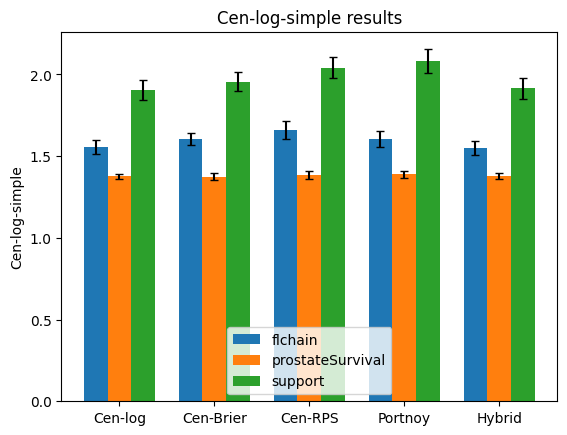

In [20]:
x=np.arange(len(methods))
width=.25

for i,name in enumerate(["flchain","prostateSurvival","support"]):
    values=[]
    errors=[]
    for method in methods:
        row=summary[(summary["Dataset"]==name)&(summary["Method"]==method)]
        values.append(row["Log mean"].iloc[0])
        errors.append(row["Log std"].iloc[0])
    plt.bar(x+(i-1)*width,values,width,yerr=errors,capsize=3,label=name)

plt.xticks(x,methods)
plt.ylabel("Cen-log-simple")
plt.title("Cen-log-simple results")
plt.legend()
plt.show()

## 12. KM-calibration plot

Lower KL divergence means the average predicted event-time distribution is closer to the Kaplan-Meier distribution.

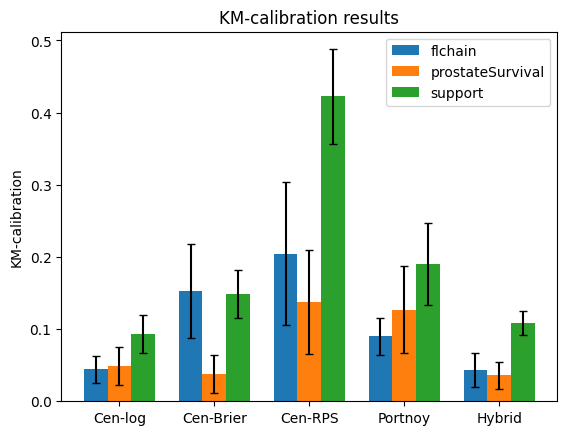

In [21]:
x=np.arange(len(methods))
width=.25

for i,name in enumerate(["flchain","prostateSurvival","support"]):
    values=[]
    errors=[]
    for method in methods:
        row=summary[(summary["Dataset"]==name)&(summary["Method"]==method)]
        values.append(row["KM mean"].iloc[0])
        errors.append(row["KM std"].iloc[0])
    plt.bar(x+(i-1)*width,values,width,yerr=errors,capsize=3,label=name)
    
plt.xticks(x,methods)
plt.ylabel("KM-calibration")
plt.title("KM-calibration results")
plt.legend()
plt.show()

## 13. D-calibration deviation plot

This plot uses my simple 20-bin deviation statistic. It is useful for comparing my models with each other, but I do not claim that its exact numeric scale is identical to the paper's code.

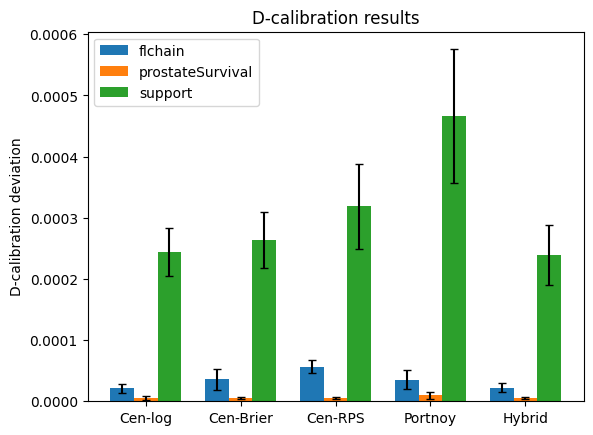

In [22]:
x=np.arange(len(methods))
width=.25

for i,name in enumerate(["flchain","prostateSurvival","support"]):
    values=[]
    errors=[]
    for method in methods:
        row=summary[(summary["Dataset"]==name)&(summary["Method"]==method)]
        values.append(row["D-cal mean"].iloc[0])
        errors.append(row["D-cal std"].iloc[0])
    plt.bar(x+(i-1)*width,values,width,yerr=errors,capsize=3,label=name)

plt.xticks(x,methods)
plt.ylabel("D-calibration deviation")
plt.title("D-calibration results")
plt.legend()
plt.show()

## 14. Direct comparison with an exact table from the paper

Appendix Table 4 gives exact Cen-log results for `B = 32` using Cen-log-simple as the evaluation metric:

- flchain: **1.5054 +/- 0.0508**
- prostateSurvival: **1.3608 +/- 0.0295**
- support: **1.8307 +/- 0.0452**

The next table compares those values with my five-run Cen-log results.

In [23]:
# the exact Cen-log numbers of Table 4 of the paper, for B = 32
paper_log={"flchain":[1.5054,.0508],"prostateSurvival":[1.3608,.0295],"support":[1.8307,.0452]}

compare=[]
for name in paper_log:
    row=summary[(summary["Dataset"]==name)&(summary["Method"]=="Cen-log")].iloc[0]
    paper_mean=paper_log[name][0]
    paper_std=paper_log[name][1]

    compare.append([
        name,
        row["Log mean"],
        row["Log std"],
        paper_mean,
        paper_std,
        abs(row["Log mean"]-paper_mean)
    ])
comparison=pd.DataFrame(compare,columns=[
    "Dataset","Our mean","Our SD","Paper mean","Paper SD","Difference"
])

comparison.round(4)

,Dataset,Our mean,Our SD,Paper mean,Paper SD,Difference
0,flchain,1.5581,0.0427,1.5054,0.0508,0.0527
1,prostateSurvival,1.3760,0.0161,1.3608,0.0295,0.0152
2,support,1.9051,0.0592,1.8307,0.0452,0.0744


## 15. Did the main pattern reproduce?

The next table shows the best method in each dataset for each metric in this notebook. It also helps check whether Cen-log and Cen-Brier remain competitive, as the paper reported.

In [24]:
best=[]

for name in ["flchain","prostateSurvival","support"]:
    temp=summary[summary["Dataset"]==name]
    best_log=""
    best_km=""
    best_d=""
    log_value=1e10
    km_value=1e10
    d_value=1e10

    for i in range(len(temp)):
        row=temp.iloc[i]
        if row["Log mean"]<log_value:
            log_value=row["Log mean"]
            best_log=row["Method"]
        if row["KM mean"]<km_value:
            km_value=row["KM mean"]
            best_km=row["Method"]
        if row["D-cal mean"]<d_value:
            d_value=row["D-cal mean"]
            best_d=row["Method"]
    best.append([name,best_log,best_km,best_d])

best_table=pd.DataFrame(best,columns=[
    "Dataset","Best discrimination","Best KM-calibration","Best D-calibration"
])

best_table

,Dataset,Best discrimination,Best KM-calibration,Best D-calibration
0,flchain,Hybrid,Hybrid,Cen-log
1,prostateSurvival,Cen-Brier,Hybrid,Hybrid
2,support,Cen-log,Cen-log,Hybrid


## 16. Extension: Hybrid loss

The paper reports that Cen-log and Cen-Brier are the strongest of the four proposed scoring rules in its experiments. My small extension combines them:

$$
L_{\text{Hybrid}} = 0.5\,L_{\text{Cen-log}} + 0.5\,L_{\text{Cen-Brier}}.
$$

This does not add a larger network or extra data. It only changes the training objective. A positive weighted sum of proper scores is a natural idea, although the practical IR weights are still estimated from the model, so this experiment should be treated as an empirical extension rather than a new theorem.

In [25]:
hybrid_compare=[]

for name in ["flchain","prostateSurvival","support"]:
    temp=summary[summary["Dataset"]==name]
    hybrid=temp[temp["Method"]=="Hybrid"].iloc[0]
    best_method=""
    best_score=1e10
    for method in ["Cen-log","Cen-Brier"]:
        row=temp[temp["Method"]==method].iloc[0]
        if row["Log mean"]<best_score:
            best_score=row["Log mean"]
            best_method=method
    hybrid_compare.append([
        name,
        hybrid["Log mean"],
        best_method,
        best_score,
        hybrid["Log mean"]-best_score
    ])
hybrid_table=pd.DataFrame(hybrid_compare,columns=[
    "Dataset","Hybrid log score","Best single method",
    "Best single log score","Hybrid - best single"
])

hybrid_table.round(4)

,Dataset,Hybrid log score,Best single method,Best single log score,Hybrid - best single
0,flchain,1.5501,Cen-log,1.5581,-0.0081
1,prostateSurvival,1.3764,Cen-Brier,1.3754,0.0009
2,support,1.9152,Cen-log,1.9051,0.0101


## 17. Extra reproduction: the number of time bins B

Appendix B of the paper compares the exact censored logarithmic score of Equation 4 (`Cen-log`)
with its simplified version of Equation 5 (`Cen-log-simple`) for `B = 8, 16, 32`. The simplified
version assumes that the weight is almost zero, which is only reasonable when `B` is large, so the
paper recommends `B > 16` and uses `B = 32`.

The paper reports these Cen-log-simple values (Tables 2, 3 and 4):

| B | flchain | prostateSurvival | support |
|---|---|---|---|
| 8 | 6.4618 / 6.4176 | 1.3460 / 1.3447 | 1.5422 / 1.5368 |
| 16 | 3.6774 / 3.6676 | 1.2880 / 1.3447 | 1.6017 / 1.6008 |
| 32 | 1.5054 / 1.5059 | 1.3608 / 1.3609 | 1.8307 / 1.8296 |

(first number = Cen-log as the loss, second number = Cen-log-simple as the loss).

I use three runs here instead of five to keep the running time reasonable. The score itself
depends on `B`, so only the two losses inside the same row can be compared with each other.

In [26]:
# three runs instead of five here, to keep the CPU time reasonable
b_rows=[]

for new_B in [8,16,32]:
    B=new_B
    for name in ["flchain","prostateSurvival","support"]:
        X,time,event=prepared[name]
        ids=np.arange(len(time))
        edges=make_edges(time)

        for run in range(small_runs):
            train_id,temp_id=train_test_split(ids,test_size=.4,random_state=run,stratify=event)
            val_id,test_id=train_test_split(temp_id,test_size=.5,random_state=run,stratify=event[temp_id])
            scaler=StandardScaler()
            X_train=scaler.fit_transform(X.iloc[train_id]).astype("float32")
            X_val=scaler.transform(X.iloc[val_id]).astype("float32")
            X_test=scaler.transform(X.iloc[test_id]).astype("float32")
            val=(X_val,time[val_id],event[val_id])
            for m,method in enumerate(["Cen-log","Cen-log-simple"]):
                model=train_model(X_train,time[train_id],event[train_id],edges,method,3000+10*run+m,val)
                f=predict_bins(model,X_test,edges,method)
                a=cen_log_simple_metric(f,time[test_id],event[test_id],edges)
                b=km_calibration_metric(f,time[test_id],event[test_id],edges)
                c=d_calibration_metric(f,time[test_id],event[test_id],edges)
                b_rows.append([new_B,name,method,a,b,c])
    print("B =",new_B,"finished")

B=32
bins_results=pd.DataFrame(b_rows,columns=["B","Dataset","Loss","Cen-log-simple","KM-calibration","D-calibration deviation"])
print("done")

B = 8 finished
B = 16 finished
B = 32 finished
done


In [27]:
for value in [8,16,32]:
    part=bins_results[bins_results["B"]==value]
    table=part.groupby(["Dataset","Loss"])[["Cen-log-simple","KM-calibration","D-calibration deviation"]].mean()
    print("B =",value)
    print(table.round(4).to_string())
    print()

B = 8
                                 Cen-log-simple  KM-calibration  D-calibration deviation
Dataset          Loss                                                                   
flchain          Cen-log                 8.1367          0.0034                   0.0003
                 Cen-log-simple          8.0138          0.1527                   0.0017
prostateSurvival Cen-log                 1.4697          0.0061                   0.0000
                 Cen-log-simple          1.4800          0.0098                   0.0000
support          Cen-log                 1.7074          0.0038                   0.0018
                 Cen-log-simple          1.7038          0.0221                   0.0018

B = 16
                                 Cen-log-simple  KM-calibration  D-calibration deviation
Dataset          Loss                                                                   
flchain          Cen-log                 4.4058          0.0132                   0.0000
       

## 18. The DeepHit ranking parameter

Table 1 of the paper studies DeepHit, whose loss is the simplified logarithmic score plus a
ranking term weighted by `alpha`. DeepHit with `alpha = 0` is exactly the simplified logarithmic
score, and the paper shows that all three metrics get worse as `alpha` grows, so it concludes that
`alpha` should be set to zero.

This is also the only loss in my notebook that is not proved to be proper, so it plays the role
of the improper baselines of Figure 4 of the paper.

The paper reports for Cen-log-simple: flchain 1.5059 / 1.5200 / 1.5858 / 2.0313 and support
1.8296 / 1.8481 / 1.9996 / 2.3657 for `alpha` = 0, 0.1, 1, 10.

In [28]:
alpha_rows=[]

for name in ["flchain","prostateSurvival","support"]:
    X,time,event=prepared[name]
    ids=np.arange(len(time))
    edges=make_edges(time)

    for run in range(small_runs):
        train_id,temp_id=train_test_split(ids,test_size=.4,random_state=run,stratify=event)
        val_id,test_id=train_test_split(temp_id,test_size=.5,random_state=run,stratify=event[temp_id])
        scaler=StandardScaler()
        X_train=scaler.fit_transform(X.iloc[train_id]).astype("float32")
        X_val=scaler.transform(X.iloc[val_id]).astype("float32")
        X_test=scaler.transform(X.iloc[test_id]).astype("float32")
        val=(X_val,time[val_id],event[val_id])
        for m,alpha in enumerate([0,.1,1,10]):
            model=train_model(X_train,time[train_id],event[train_id],edges,"DeepHit",4000+10*run+m,val,alpha)
            f=predict_bins(model,X_test,edges,"DeepHit")
            a=cen_log_simple_metric(f,time[test_id],event[test_id],edges)
            b=km_calibration_metric(f,time[test_id],event[test_id],edges)
            c=d_calibration_metric(f,time[test_id],event[test_id],edges)
            alpha_rows.append([name,alpha,a,b,c])
    print(name,"finished")

alpha_results=pd.DataFrame(alpha_rows,columns=["Dataset","alpha","Cen-log-simple","KM-calibration","D-calibration deviation"])
alpha_table=alpha_results.groupby(["Dataset","alpha"])[["Cen-log-simple","KM-calibration","D-calibration deviation"]].mean()

alpha_table.round(4)

flchain finished
prostateSurvival finished
support finished


Cen-log-simple  KM-calibration  \
Dataset          alpha                                   
flchain          0.0            1.5577          0.0250   
                 0.1            1.9258          0.4407   
                 1.0            2.5266          1.3521   
                 10.0           2.6440          1.6642   
prostateSurvival 0.0            1.3794          0.0499   
                 0.1            1.4182          0.2450   
                 1.0            1.4826          0.5595   
                 10.0           1.4895          0.6263   
support          0.0            1.9140          0.1544   
                 0.1            2.2522          0.6083   
                 1.0            2.3549          0.8189   
                 10.0           2.3735          0.8693   

                        D-calibration deviation  
Dataset          alpha                           
flchain          0.0                     0.0000  
                 0.1                     0.0010  
                 1.0                     0.0044  
                 10.0                    0.0052  
prostateSurvival 0.0                     0.0000  
                 0.1                     0.0000  
                 1.0                     0.0002  
                 10.0                    0.0002  
support          0.0                     0.0003  
                 0.1                     0.0020  
                 1.0                     0.0028  
                 10.0                    0.0029

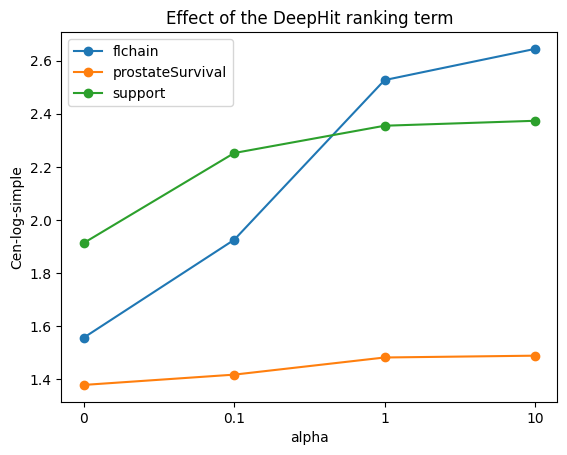

In [29]:
for name in ["flchain","prostateSurvival","support"]:
    part=alpha_results[alpha_results["Dataset"]==name]
    values=part.groupby("alpha")["Cen-log-simple"].mean()
    plt.plot(range(len(values)),values.values,marker="o",label=name)

plt.xticks(range(4),["0","0.1","1","10"])
plt.xlabel("alpha")
plt.ylabel("Cen-log-simple")
plt.title("Effect of the DeepHit ranking term")
plt.legend()
plt.show()

## 19. Final interpretation

This reproduction uses the three real datasets and the same main settings as the paper: 32 time
bins, three hidden layers with 128 neurons, ReLU, softmax, Adam with learning rate 0.001, and five
random 60/20/20 splits.

What reproduced:

- **The ordering of the scoring rules.** Cen-log and Cen-Brier are the strongest of the four
  proposed rules, as the paper reports, and Cen-RPS and Portnoy are behind them. The paper explains
  this by the weights: in Cen-log and Cen-Brier they are usually close to 0 or 1, while in Cen-RPS
  and Portnoy they can take any value between 0 and 1 and are therefore harder to estimate.
- **The exact Cen-log values.** My numbers are within about 0.015 to 0.075 of the values in Table 4
  of the paper on all three datasets, which is within about one to two standard deviations reported in the paper.
- **The effect of alpha in DeepHit.** Performance generally gets worse as alpha grows, so alpha = 0 is the
  best choice in my results. This gives the same qualitative trend as Table 1 of the paper.
- **Equation 4 against Equation 5.** The exact Cen-log version was clearly better calibrated for smaller B in my runs. At B=32, the difference became small and was not always in the same direction. This supports the paper's main point that the two versions become more similar when B is large.

The results should not be expected to match exactly because:

- I use 75 epochs instead of 300, with the validation split used to keep the best checkpoint.
- The paper does not fully specify the feature preprocessing, so I use my own transparent pipeline.
- I use full-batch training to keep the CPU code simple.
- My D-calibration is a simple deviation statistic and not the exact statistic of the original code.
- Portnoy uses a simple grid estimate of the censoring quantile.
- I did not implement the DRSA, S-CRPS and IPCW baselines of Figure 4; DeepHit with alpha > 0 is
  the improper baseline in my version.

The Hybrid extension of Section 16 shows that mixing Cen-log and Cen-Brier does not give a clear
improvement over the better of the two, which fits the argument of the paper that the two rules
already behave in a very similar way.